In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    names=["ID","Title","Genre","Description"]
)

df.head()

,ID,Title,Genre,Description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [6]:

df.shape

(54214, 4)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           54214 non-null  int64
 1   Title        54214 non-null  str  
 2   Genre        54214 non-null  str  
 3   Description  54214 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.7 MB


In [8]:
df.describe(include='all')

,ID,Title,Genre,Description
count,54214.000000,54214,54214,54214
unique,NaN,54214,27,54086
top,NaN,Oscar et la dame rose (2009),drama,Grammy - music award of the American academy o...
freq,NaN,1,13613,12
mean,27107.500000,NaN,NaN,NaN
std,15650.378084,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,13554.250000,NaN,NaN,NaN
50%,27107.500000,NaN,NaN,NaN
75%,40660.750000,NaN,NaN,NaN


In [9]:
df.isnull().sum()

ID             0
Title          0
Genre          0
Description    0
dtype: int64

In [10]:
df = df.dropna()

df.shape

(54214, 4)

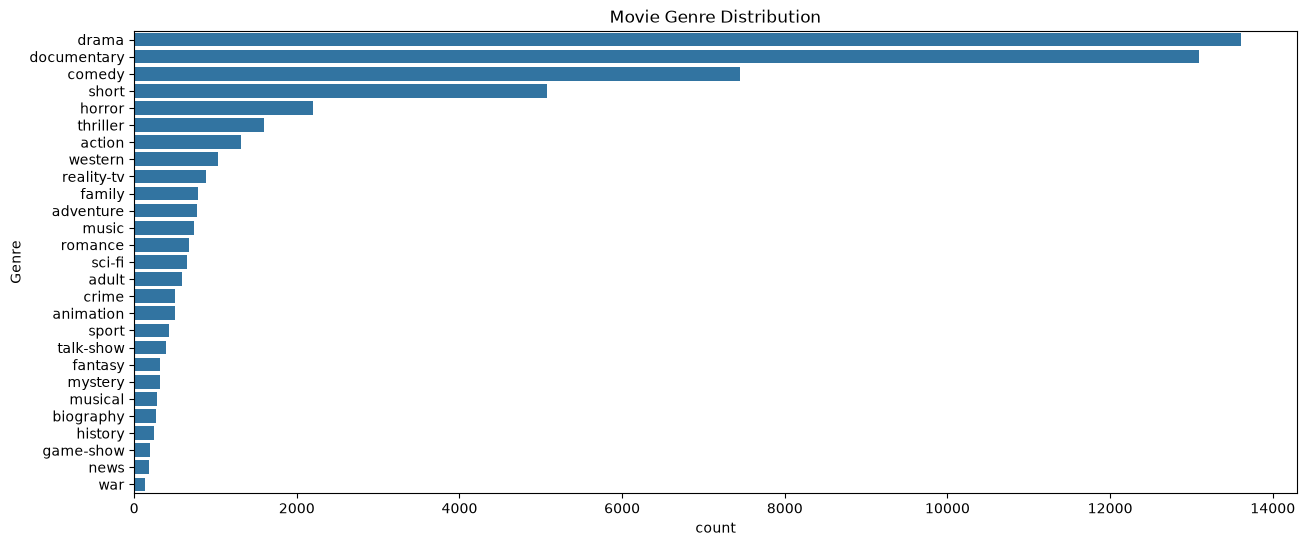

In [11]:
plt.figure(figsize=(15,6))

sns.countplot(y=df["Genre"],
              order=df["Genre"].value_counts().index)

plt.title("Movie Genre Distribution")
plt.show()

In [12]:
X = df["Description"]

y = df["Genre"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [15]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](27,)","[1052., 478., 636.,...,1282., 112., 832.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](27,)","[-3.72,-4.51,-4.22,...,-3.52,-5.96,-3.95]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U11](27,)","['action','adult','adventure',...,'thriller','war','western']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](27, 5000)","[[2.24,1.19,1.64,...,1.09,1.84,0.55], [0.42,0.68,0. ,...,0.25,0. ,0. ], [0.89,1.41,0.31,...,1.23,0.18,0.22], ..., [1.2 ,1.29,1.6 ,...,0.83,0.94,0.55], [0.7 ,0.46,0. ,...,0. ,0. ,0.48], [2.04,1.12,0.38,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](27, 5000)","[[-8.07,-8.46,-8.27,...,-8.5 ,-8.2 ,-8.81], [-8.54,-8.37,-8.89,...,-8.67,-8.89,-8.89], [-8.37,-8.12,-8.73,...,-8.2 ,-8.84,-8.8 ], ..., [-8.57,-8.53,-8.41,...,-8.76,-8.7 ,-8.92], [-8.1 ,-8.25,-8.63,...,-8.63,-8.63,-8.23], [-8.01,-8.38,-8.8 ,...,-9.13,-9.13,-9.13]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [16]:
pred_nb = nb.predict(X_test)

In [17]:
accuracy_score(y_test,pred_nb)

0.5231946878170248

In [18]:
print(classification_report(y_test,pred_nb))

              precision    recall  f1-score   support

      action       0.58      0.08      0.14       263
       adult       0.88      0.06      0.12       112
   adventure       0.29      0.03      0.05       139
   animation       0.00      0.00      0.00       104
   biography       0.00      0.00      0.00        61
      comedy       0.51      0.44      0.47      1443
       crime       0.00      0.00      0.00       107
 documentary       0.58      0.88      0.70      2659
       drama       0.46      0.83      0.59      2697
      family       1.00      0.01      0.01       150
     fantasy       0.00      0.00      0.00        74
   game-show       1.00      0.15      0.26        40
     history       0.00      0.00      0.00        45
      horror       0.73      0.36      0.48       431
       music       0.77      0.12      0.20       144
     musical       0.00      0.00      0.00        50
     mystery       0.00      0.00      0.00        56
        news       0.00    

c:\Users\shahid khan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shahid khan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shahid khan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy :",accuracy_score(y_test,pred_lr))

Accuracy : 0.5794521811306834


In [20]:
svm = LinearSVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

print("Accuracy :",accuracy_score(y_test,pred_svm))

Accuracy : 0.5704140920409481


In [21]:
print("Naive Bayes :",accuracy_score(y_test,pred_nb))

print("Logistic Regression :",accuracy_score(y_test,pred_lr))

print("SVM :",accuracy_score(y_test,pred_svm))

Naive Bayes : 0.5231946878170248
Logistic Regression : 0.5794521811306834
SVM : 0.5704140920409481


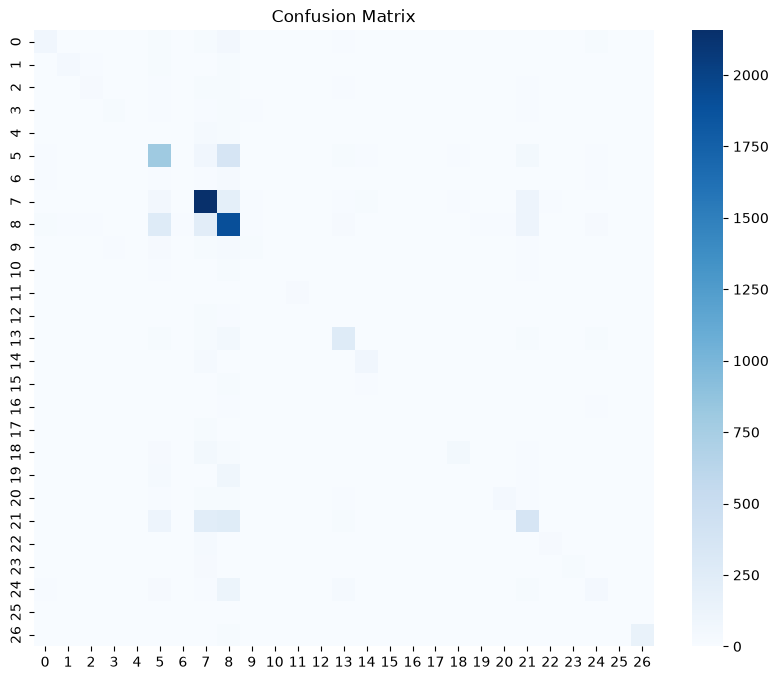

In [22]:
cm = confusion_matrix(y_test,pred_svm)

plt.figure(figsize=(10,8))

sns.heatmap(cm,cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [23]:
movie = ["A young detective investigates a mysterious murder in a small town."]

movie_vector = tfidf.transform(movie)

prediction = svm.predict(movie_vector)

print("Predicted Genre :",prediction[0])

Predicted Genre : mystery
